<Figure size 1200x600 with 0 Axes>

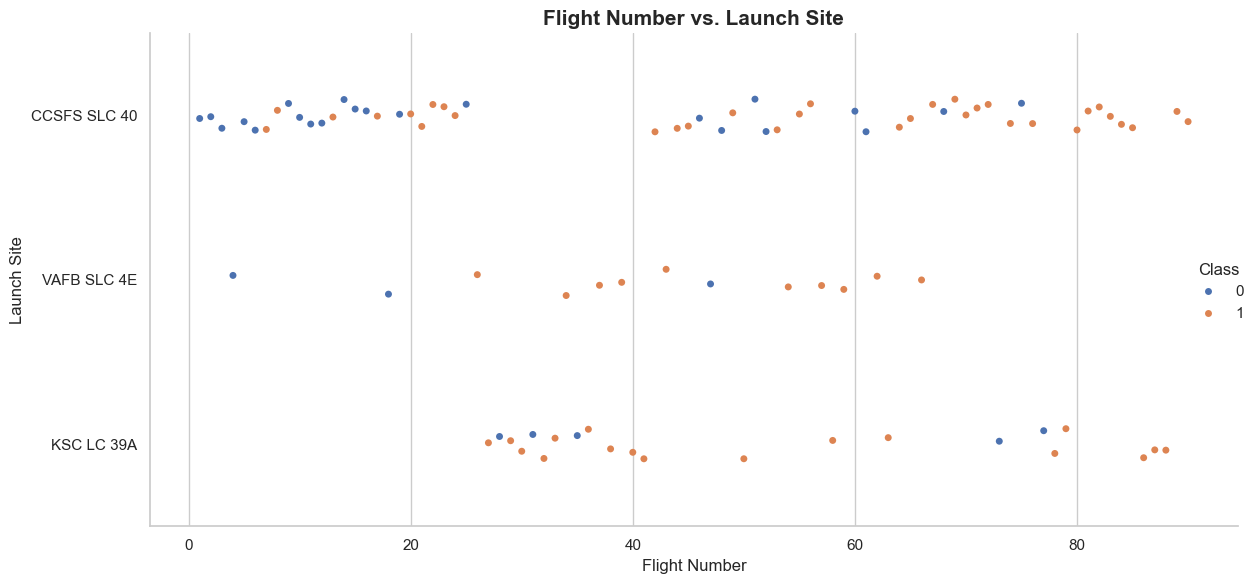

<Figure size 1200x600 with 0 Axes>

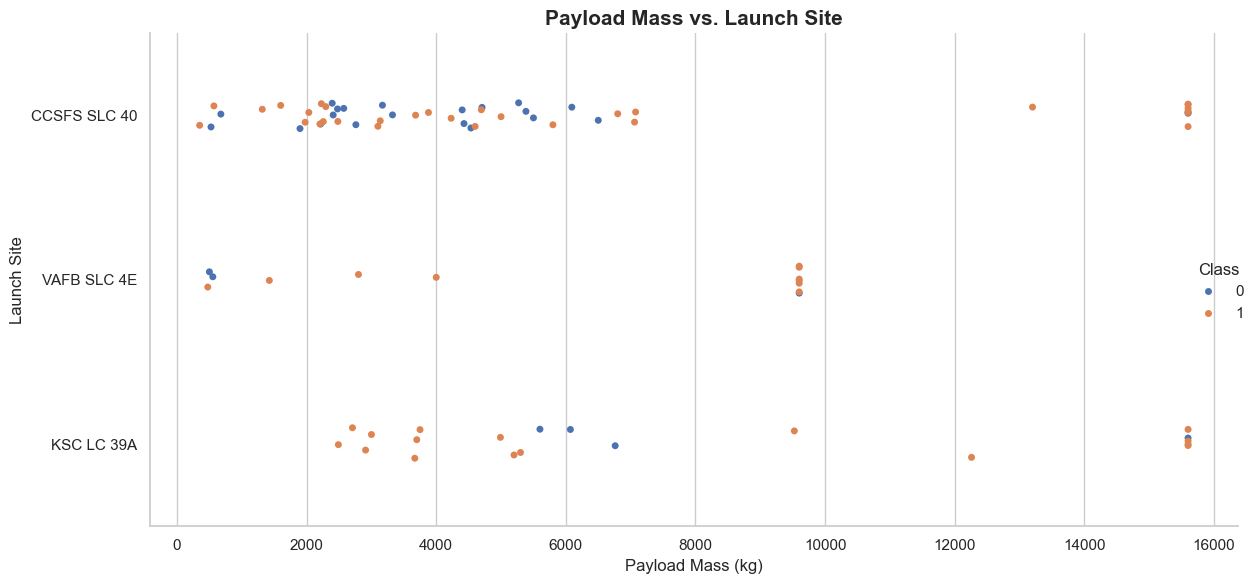

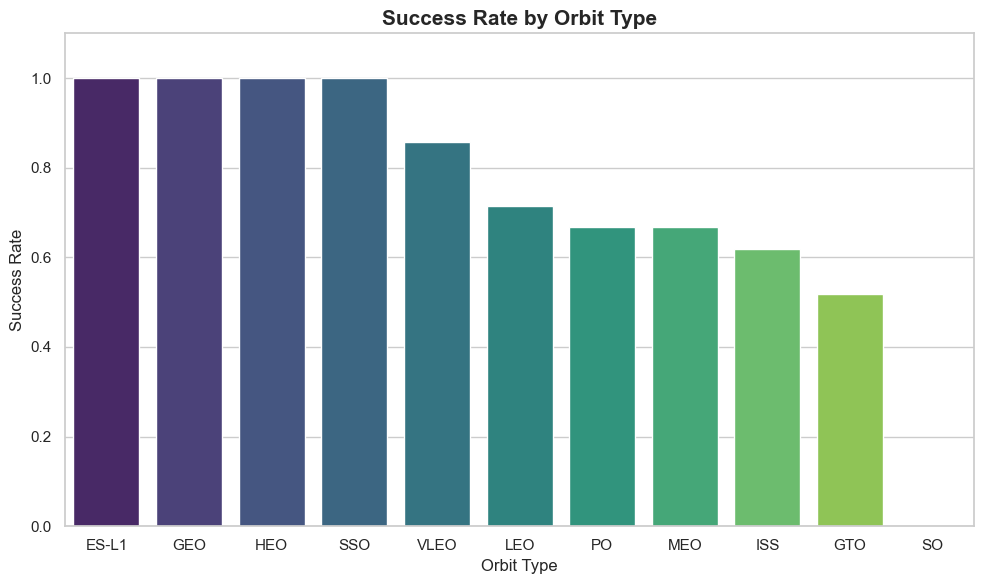

<Figure size 1200x600 with 0 Axes>

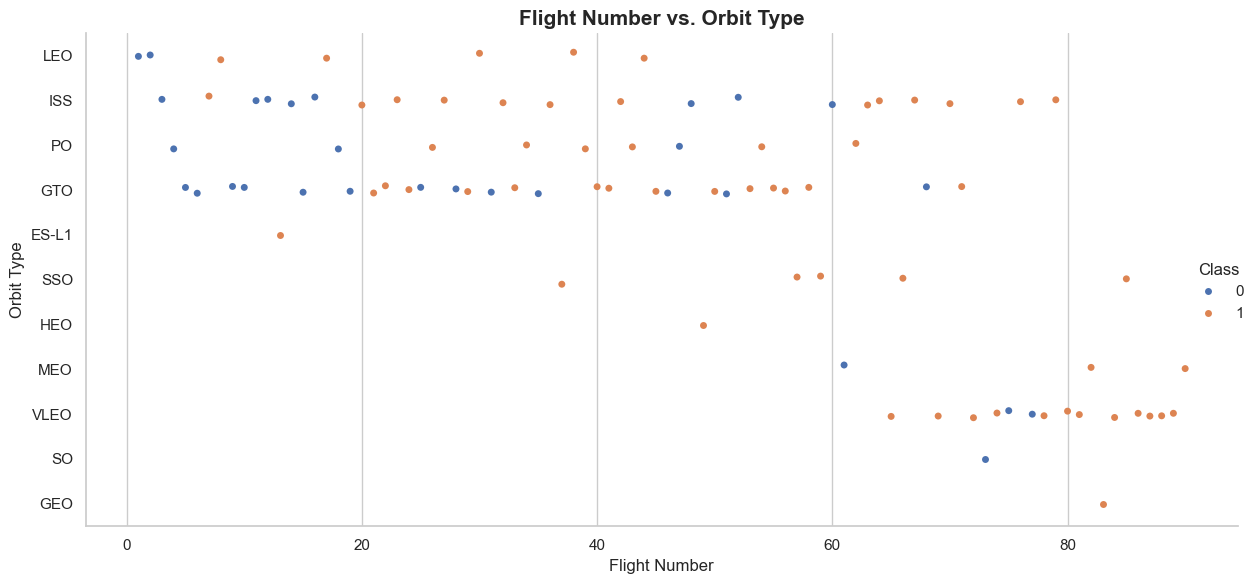

<Figure size 1200x600 with 0 Axes>

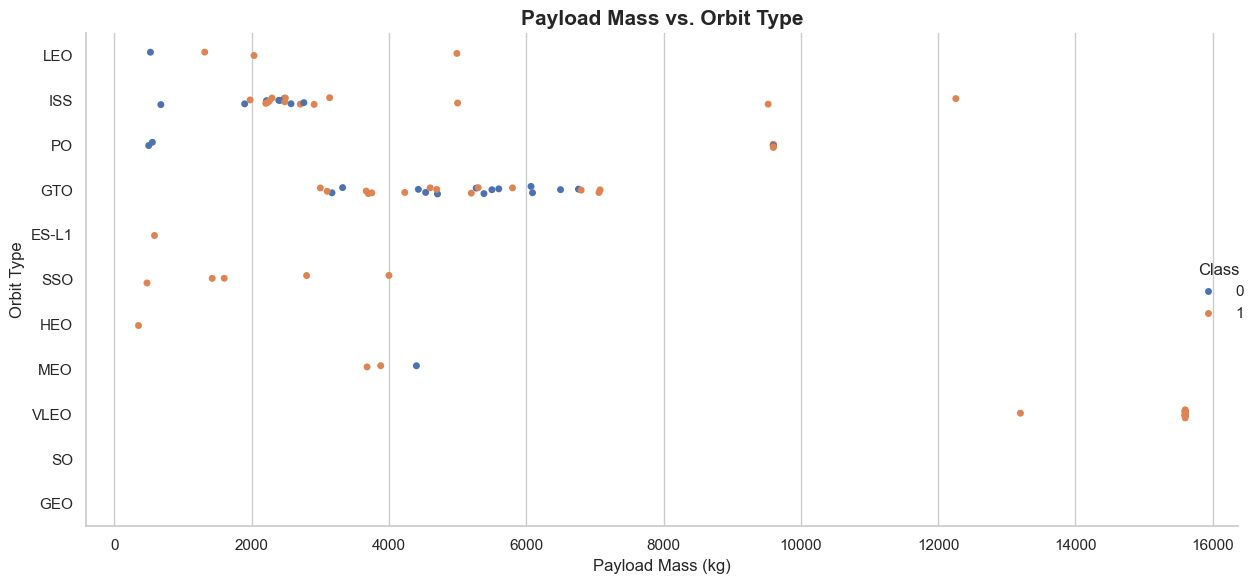

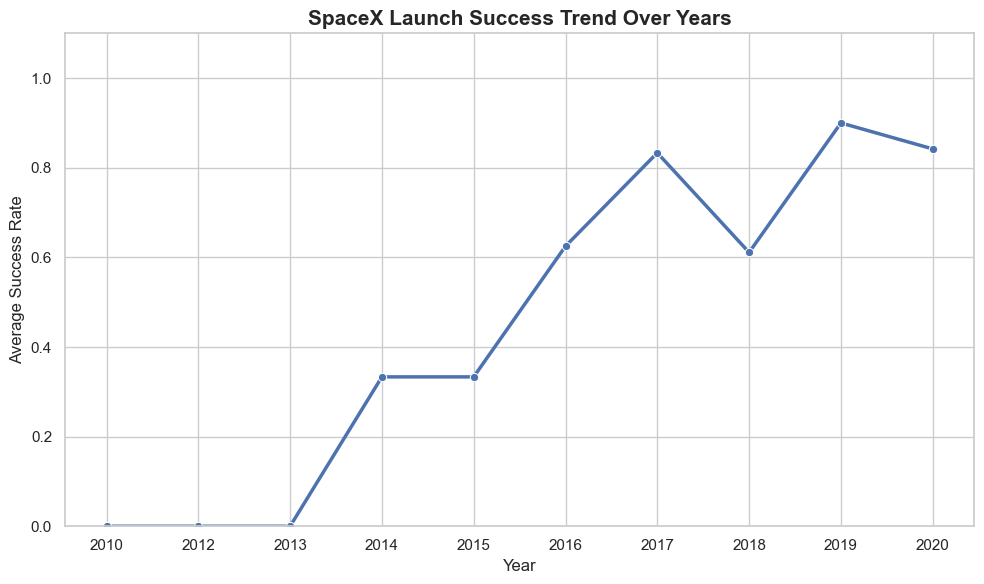


Biến đổi đặc trưng One-hot encoding hoàn tất!
File 'dataset_part_3.csv' đã được lưu để chuẩn bị cho phần Predictive Analysis.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Đọc dữ liệu từ file dataset_part_2.csv đã làm sạch ở Bước 3
df = pd.read_csv("dataset_part_2.csv")

# Thiết lập style cho biểu đồ đẹp hơn
sns.set_theme(style="whitegrid")

# --- BIỂU ĐỒ 1: Flight Number vs. Launch Site ---
plt.figure(figsize=(12, 6))
sns.catplot(y="LaunchSite", x="FlightNumber", hue="Class", data=df, aspect=2, height=6)
plt.title("Flight Number vs. Launch Site", fontsize=15, fontweight='bold')
plt.xlabel("Flight Number", fontsize=12)
plt.ylabel("Launch Site", fontsize=12)
plt.tight_layout()
plt.savefig("flight_no_vs_launch_site.png", dpi=300)
plt.show()

# --- BIỂU ĐỒ 2: Payload Mass vs. Launch Site ---
plt.figure(figsize=(12, 6))
sns.catplot(y="LaunchSite", x="PayloadMass", hue="Class", data=df, aspect=2, height=6)
plt.title("Payload Mass vs. Launch Site", fontsize=15, fontweight='bold')
plt.xlabel("Payload Mass (kg)", fontsize=12)
plt.ylabel("Launch Site", fontsize=12)
plt.tight_layout()
plt.savefig("payload_vs_launch_site.png", dpi=300)
plt.show()

# --- BIỂU ĐỒ 3: Success Rate of each Orbit Type (Bar Chart) ---
plt.figure(figsize=(10, 6))
# Tính toán tỉ lệ thành công theo từng quỹ đạo (Orbit)
orbit_success = df.groupby('Orbit')['Class'].mean().reset_index()
orbit_success = orbit_success.sort_values(by='Class', ascending=False)

sns.barplot(x="Orbit", y="Class", data=orbit_success, hue="Orbit", palette="viridis", legend=False)
plt.title("Success Rate by Orbit Type", fontsize=15, fontweight='bold')
plt.xlabel("Orbit Type", fontsize=12)
plt.ylabel("Success Rate", fontsize=12)
plt.ylim(0, 1.1)
plt.tight_layout()
plt.savefig("success_rate_by_orbit.png", dpi=300)
plt.show()

# --- BIỂU ĐỒ 4: Flight Number vs. Orbit Type ---
plt.figure(figsize=(12, 6))
sns.catplot(y="Orbit", x="FlightNumber", hue="Class", data=df, aspect=2, height=6)
plt.title("Flight Number vs. Orbit Type", fontsize=15, fontweight='bold')
plt.xlabel("Flight Number", fontsize=12)
plt.ylabel("Orbit Type", fontsize=12)
plt.tight_layout()
plt.savefig("flight_no_vs_orbit.png", dpi=300)
plt.show()

# --- BIỂU ĐỒ 5: Payload Mass vs. Orbit Type ---
plt.figure(figsize=(12, 6))
sns.catplot(y="Orbit", x="PayloadMass", hue="Class", data=df, aspect=2, height=6)
plt.title("Payload Mass vs. Orbit Type", fontsize=15, fontweight='bold')
plt.xlabel("Payload Mass (kg)", fontsize=12)
plt.ylabel("Orbit Type", fontsize=12)
plt.tight_layout()
plt.savefig("payload_vs_orbit.png", dpi=300)
plt.show()

# --- BIỂU ĐỒ 6: Yearly Trend of Launch Success Rate (Line Chart) ---
# Hàm phụ trợ để trích xuất năm từ cột Date
def Extract_year(date_series):
    return [date.split("-")[0] for date in date_series]

df['Year'] = Extract_year(df['Date'])
yearly_success = df.groupby('Year')['Class'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(x="Year", y="Class", data=yearly_success, marker='o', color='b', linewidth=2.5)
plt.title("SpaceX Launch Success Trend Over Years", fontsize=15, fontweight='bold')
plt.xlabel("Year", fontsize=12)
plt.ylabel("Average Success Rate", fontsize=12)
plt.ylim(0, 1.1)
plt.tight_layout()
plt.savefig("success_trend_by_year.png", dpi=300)
plt.show()

# --- BƯỚC CHUẨN BỊ CHO MACHINE LEARNING (DUMMY VARIABLES / ONE-HOT ENCODING) ---
# Ở cuối bài lab viz này, chúng ta cần chuyển đổi các biến phân loại thành biến dummy 0-1
features = df[['FlightNumber', 'PayloadMass', 'Orbit', 'LaunchSite', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial']]
features_one_hot = pd.get_dummies(features, columns=['Orbit', 'LaunchSite', 'LandingPad', 'Serial'])

# Chuyển đổi tất cả các cột sang float64
features_one_hot = features_one_hot.astype('float64')

# Lưu các biến đặc trưng (features) thành file csv part 3 để dùng cho bài ML sau này
features_one_hot.to_csv('dataset_part_3.csv', index=False)
print("\nBiến đổi đặc trưng One-hot encoding hoàn tất!")
print("File 'dataset_part_3.csv' đã được lưu để chuẩn bị cho phần Predictive Analysis.")